# Phase 1: Synthetic Tasks — Hidden-Layer Perturbation Results

This notebook visualises the results of the Phase 1 synthetic experiments.  
At test time, a fraction **f** of hidden-layer spikes are replaced with random spikes (preserving spike count per neuron).  
- **f = 0**: hidden output untouched (full temporal code available).  
- **f = 1**: all temporal structure destroyed (rate-only internal signal).

Two model variants are compared:
- **Learnable Tau** — baseline SNN with learnable membrane time constants only.
- **Tau + Delay** — SNN with both learnable time constants and learnable axonal delays.

In [1]:
import json
import pathlib
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

BASE = pathlib.Path(".")  # notebook lives in code/synthetic/

## ISI & CCISI - Dataset Feature Space

Both the ISI and CCISI tasks share the same 2-D feature space: each sample is defined by a **Firing Rate** (Hz) and an **ISI / CCISI interval** (ms).  
Classes are separated by a linear decision boundary in this plane.  A vertical **Rate-only Threshold** shows the best separation achievable using firing rate alone — any accuracy above this line requires temporal (ISI) information.

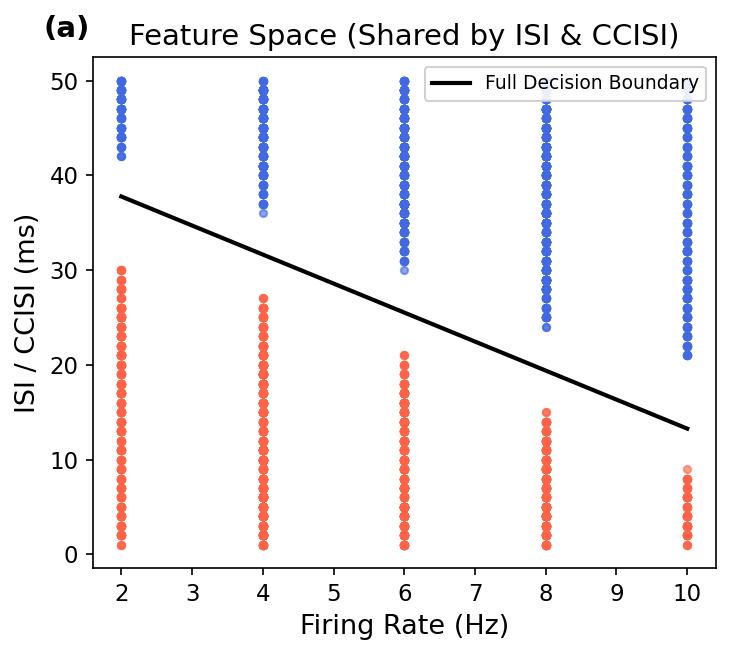

In [2]:
# --- Load dataset (ISI and CCISI share the same feature space) ---
with h5py.File(BASE / "isi/isi_dataset.h5", "r") as f:
    firing_rates = f["firing_rates"][:]
    isis_vals = f["isis"][:]
    labels = f["Y"][:]

# --- Reproduce col_min / col_max from the original data generation ---
# Both ISI and CCISI data generators use np.random.seed(42) with the same
# point-sampling and filtering parameters, so the column extremes are identical.
_rng = np.random.RandomState(42)
_pts = _rng.uniform(-10, 10, (5000, 2))
_slope, _intercept = -0.5, 0.0
_dist = np.abs(_slope * _pts[:, 0] - _pts[:, 1] + _intercept) / np.sqrt(_slope ** 2 + 1)
_pts = _pts[_dist >= 2.5]
col_min, col_max = _pts.min(axis=0), _pts.max(axis=0)

# --- Decision boundary in mapped (FR, ISI) space ---
x_raw = np.linspace(col_min[0], col_max[0], 200)
y_raw = _slope * x_raw + _intercept
fr_boundary = (x_raw - col_min[0]) / (col_max[0] - col_min[0]) * (10 - 2) + 2
isi_boundary = (y_raw - col_min[1]) / (col_max[1] - col_min[1]) * (50 - 1) + 1

'''# --- Rate-only threshold (best vertical split using only firing rate) ---
unique_fr = np.unique(firing_rates)
best_acc, best_thr = 0.0, unique_fr[len(unique_fr) // 2]
for thr in unique_fr:
    acc = max(
        ((firing_rates <= thr) == (labels == 1)).mean(),
        ((firing_rates <= thr) == (labels == 0)).mean(),
    )
    if acc > best_acc:
        best_acc, best_thr = acc, thr'''

# --- Plot ---
fig, ax = plt.subplots(figsize=(5.0, 4.5))

ax.scatter(firing_rates[labels == 0], isis_vals[labels == 0],
           color="royalblue", s=12, alpha=0.6, zorder=2)
ax.scatter(firing_rates[labels == 1], isis_vals[labels == 1],
           color="tomato", s=12, alpha=0.6, zorder=2)

ax.plot(fr_boundary, isi_boundary, color="black", linewidth=2.0,
        label="Full Decision Boundary", zorder=3)

'''ax.axvline(best_thr, color="gray", linestyle="--", linewidth=1.8,
           label="Rate-only Threshold", zorder=3)'''

ax.set_xlabel("Firing Rate (Hz)")
ax.set_ylabel("ISI / CCISI (ms)")
ax.set_title("Feature Space (Shared by ISI & CCISI)")
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)

# subplot label
ax.text(-0.08, 1.04, "(a)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("feature_space_isi_ccisi.png", dpi=300, bbox_inches="tight")
plt.show()

## ISI & CCISI - Hidden-Layer Spike Rasters (Original vs Perturbed)

Unlike the original paper where perturbation is applied to the **input**, our experiments apply it to the **output of the first hidden layer**.  
Below we pass one example through the trained Tau+Delay model, extract the 100-neuron hidden-layer spike train, and compare:
- **Top row**: original hidden output (temporal structure intact).
- **Bottom row**: the same hidden output after randomising 50 % of each neuron's spikes (f = 0.5).

Only the first 1 000 ms are shown for readability.

d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


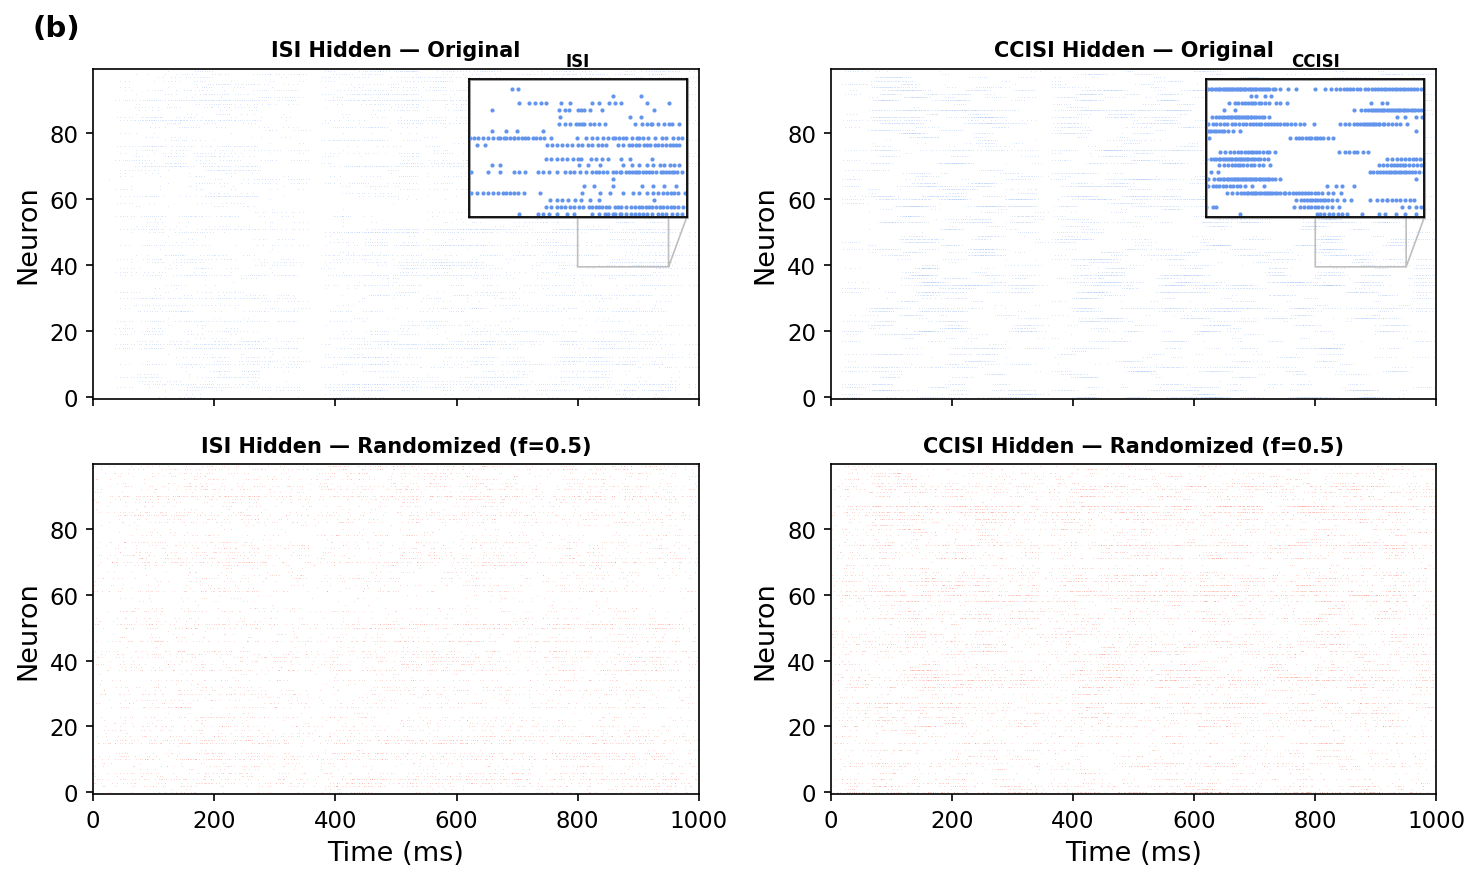

In [3]:
import slayerSNN as snn
from torch import nn

# ===================== SLAYER parameters (2000-rate setup) =====================
MS = 1e-3
_TS_MS = 0.5  # 0.5 ms / step => 2000 Hz sampling rate
_SIM_PARAMS = {"Ts": _TS_MS, "tSample": 1000}
_LIF_PARAMS = {
    "type": "SRMALPHA", "theta": 1,
    "tauSr": 1, "tauRho": 1, "tauRef": 1,
    "scaleRef": 2, "scaleRho": 1,
}

# Temporal-receptive-field knobs rescaled to keep physical timing identical
# to the 1000-rate baseline (50 ms PSP filter, ISI delay=15 ms, CCISI delay=10 ms).
_FILTER_LEN = 100              # 100 taps * 0.5 ms = 50 ms
_ISI_MAX_DELAY = 30            # 30 steps  * 0.5 ms = 15 ms
_CCISI_MAX_DELAY = 20          # 20 steps  * 0.5 ms = 10 ms

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ===================== Model definitions =====================
def _init_alpha_filter(psp_filter, slayer_obj):
    """Seed the learnable PSP filter with an alpha-function shape."""
    tau = 50 * MS
    Ts = slayer_obj.simulation["Ts"] * MS
    filt_len = psp_filter.weight.shape[-1]
    ak = np.array([t / tau * np.exp(1 - t / tau)
                    for t in np.arange(0, filt_len * Ts, Ts)])
    if np.max(np.abs(ak)) > 0:
        ak /= np.max(np.abs(ak))
    with torch.no_grad():
        psp_filter.weight.data = torch.FloatTensor(
            np.flip(ak).copy()
        ).reshape(psp_filter.weight.shape)


class _ISIDelayNet(nn.Module):
    def __init__(self, num_neurons, num_classes, hidden_units=100,
                 max_delay=_ISI_MAX_DELAY):
        super().__init__()
        sl = snn.layer(_LIF_PARAMS, _SIM_PARAMS)
        self.slayer = sl
        self.fc1 = nn.utils.weight_norm(sl.dense(num_neurons, hidden_units), name="weight")
        self.fc2 = nn.utils.weight_norm(sl.dense(hidden_units, num_classes), name="weight")
        self.psp_filter = sl.pspFilter(nFilter=1, filterLength=_FILTER_LEN, filterScale=1)
        _init_alpha_filter(self.psp_filter, sl)
        self.delay1 = sl.delay(num_neurons)
        self.delay2 = sl.delay(hidden_units)
        with torch.no_grad():
            self.delay1.delay.data.uniform_(0, max_delay)
            self.delay2.delay.data.uniform_(0, max_delay)

    def first_layer(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        x = x.float().to(_device)
        x = self.delay1(x)
        return self.slayer.spike(self.fc1(self.psp_filter(x)))


class _CCISIDelayNet(nn.Module):
    def __init__(self, num_neurons, num_classes, hidden_units=100,
                 max_delay=_CCISI_MAX_DELAY):
        super().__init__()
        sl = snn.layer(_LIF_PARAMS, _SIM_PARAMS)
        self.slayer = sl
        self.fc1 = nn.utils.weight_norm(sl.dense(num_neurons, hidden_units), name="weight")
        self.fc2 = nn.utils.weight_norm(sl.dense(hidden_units, num_classes), name="weight")
        self.psp_filter = sl.pspFilter(nFilter=1, filterLength=_FILTER_LEN, filterScale=1)
        _init_alpha_filter(self.psp_filter, sl)
        self.delay1 = sl.delay(num_neurons)
        self.delay2 = sl.delay(hidden_units)
        with torch.no_grad():
            self.delay1.delay.data.uniform_(0, max_delay)
            self.delay2.delay.data.uniform_(0, max_delay)

    def first_layer(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        x = x.float().to(_device)
        x = self.delay1(x)
        return self.slayer.spike(self.fc1(self.psp_filter(x)))


# ===================== Perturbation =====================
def _partial_randomize(spike_train: np.ndarray, f: float) -> np.ndarray:
    """Relocate fraction *f* of each neuron's spikes to random empty bins.

    SLAYER outputs 1/Ts per spike (2.0 at Ts=0.5), so we detect spikes with
    > 0.5 and re-emit relocated spikes at the same magnitude.
    """
    if f <= 0:
        return spike_train
    out = spike_train.copy()
    num_neurons, T = out.shape
    for n in range(num_neurons):
        st = np.where(spike_train[n] > 0.5)[0]
        if len(st) == 0:
            continue
        spike_value = float(spike_train[n, st[0]])
        num_move = int(len(st) * f)
        if num_move == 0:
            continue
        chosen = np.random.choice(st, size=num_move, replace=False)
        out[n, chosen] = 0
        placed = 0
        for _ in range(50 * num_move):
            if placed >= num_move:
                break
            t = np.random.randint(0, T)
            if out[n, t] < 0.5:
                out[n, t] = spike_value
                placed += 1
    return out


# ===================== Load models & data =====================
isi_net = _ISIDelayNet(10, 2, 100, _ISI_MAX_DELAY).to(_device)
isi_net.load_state_dict(torch.load(BASE / "isi/data/isi_delay_trained.pt", map_location=_device))
isi_net.eval()

ccisi_net = _CCISIDelayNet(20, 2, 100, _CCISI_MAX_DELAY).to(_device)
ccisi_net.load_state_dict(torch.load(BASE / "ccisi/data/ccisi_delay_trained.pt", map_location=_device))
ccisi_net.eval()

with h5py.File(BASE / "isi/isi_dataset.h5", "r") as fh:
    isi_x = torch.from_numpy(fh["X"][0:1])   # (1, 10, T=2000)
with h5py.File(BASE / "ccisi/ccisi_dataset.h5", "r") as fh:
    ccisi_x = torch.from_numpy(fh["X"][0:1])  # (1, 20, T=2000)

with torch.no_grad():
    isi_hidden = isi_net.first_layer(isi_x)[0, :, 0, 0, :].cpu().numpy()    # (100, T)
    ccisi_hidden = ccisi_net.first_layer(ccisi_x)[0, :, 0, 0, :].cpu().numpy()

np.random.seed(0)
isi_perturbed = _partial_randomize(isi_hidden, f=0.5)
ccisi_perturbed = _partial_randomize(ccisi_hidden, f=0.5)

# ===================== Plot =====================
# Show the full 1000 ms window. Step indices are converted to ms via _TS_MS
# so the x-axis matches the 1000-rate baseline visually.
SHOW_T_MS = 1000
SHOW_T_STEPS = int(SHOW_T_MS / _TS_MS)  # 2000 steps at Ts=0.5

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

panels = [
    (axes[0, 0], isi_hidden[:, :SHOW_T_STEPS],     "ISI Hidden — Original",                "cornflowerblue"),
    (axes[0, 1], ccisi_hidden[:, :SHOW_T_STEPS],    "CCISI Hidden — Original",              "cornflowerblue"),
    (axes[1, 0], isi_perturbed[:, :SHOW_T_STEPS],   "ISI Hidden — Randomized (f=0.5)",      "tomato"),
    (axes[1, 1], ccisi_perturbed[:, :SHOW_T_STEPS], "CCISI Hidden — Randomized (f=0.5)",    "tomato"),
]

for ax, spikes, title, color in panels:
    neurons, times = np.where(spikes > 0.5)
    ax.scatter(times * _TS_MS, neurons, s=0.15, c=color, marker=".",
               linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylim(-0.5, 99.5)
    ax.set_xlim(0, SHOW_T_MS)
    ax.set_ylabel("Neuron")

# Zoom insets on top-row panels — region specified in ms for clarity.
for ax, spikes, label in [
    (axes[0, 0], isi_hidden[:, :SHOW_T_STEPS], "ISI"),
    (axes[0, 1], ccisi_hidden[:, :SHOW_T_STEPS], "CCISI"),
]:
    region_t_ms = (800, 950)
    region_n = (40, 60)
    region_t_steps = (int(region_t_ms[0] / _TS_MS), int(region_t_ms[1] / _TS_MS))
    inset = ax.inset_axes([0.62, 0.55, 0.36, 0.42])
    sub = spikes[region_n[0]:region_n[1], region_t_steps[0]:region_t_steps[1]]
    ns, ts = np.where(sub > 0.5)
    inset.scatter((ts + region_t_steps[0]) * _TS_MS, ns + region_n[0],
                  s=4, c="cornflowerblue", marker="o", linewidths=0)
    inset.set_xlim(region_t_ms)
    inset.set_ylim(region_n[0] - 0.5, region_n[1] - 0.5)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title(label, fontsize=8, fontweight="bold")
    inset.patch.set_edgecolor("gray")
    inset.patch.set_linewidth(1.2)
    ax.indicate_inset_zoom(inset, edgecolor="gray", linewidth=0.8)

for ax in axes[1, :]:
    ax.set_xlabel("Time (ms)")

axes[0, 0].text(-0.10, 1.10, "(b)", transform=axes[0, 0].transAxes,
                fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()

## ISI & CCISI - Accuracy vs Hidden-Layer Perturbation

Both ISI and CCISI tasks encode class information purely in spike timing.  
This plot shows how accuracy degrades as hidden-layer temporal structure is progressively destroyed.  
The dashed **FR Only Baseline** line marks the accuracy of a rate-only model (f = 1 on the worse-performing variant), giving a lower-bound reference.

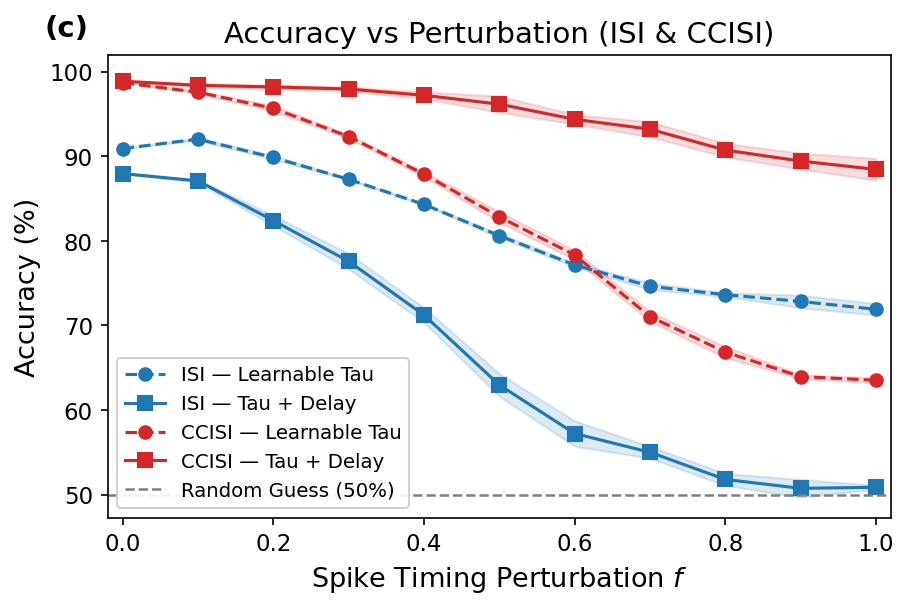

In [4]:
def load_results(path: pathlib.Path) -> dict:
    """Load a perturbation results JSON and return (f_values, means, stds)."""
    with open(path) as fh:
        raw = json.load(fh)
    f_vals = sorted(float(k) for k in raw)
    means = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["mean"] for f in f_vals]) * 100
    stds = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["std"] for f in f_vals]) * 100
    return f_vals, means, stds


# --- load ISI results ---
isi_tau_f, isi_tau_mean, isi_tau_std = load_results(BASE / "isi/log/isi_tau_hidden_perturbation_results.json")
isi_del_f, isi_del_mean, isi_del_std = load_results(BASE / "isi/log/isi_delay_hidden_perturbation_results.json")

# --- load CCISI results ---
cc_tau_f, cc_tau_mean, cc_tau_std = load_results(BASE / "ccisi/log/ccisi_tau_hidden_perturbation_results.json")
cc_del_f, cc_del_mean, cc_del_std = load_results(BASE / "ccisi/log/ccisi_delay_hidden_perturbation_results.json")

# --- FR-only baseline: worst f=1 accuracy across all four curves ---
#fr_baseline = min(isi_tau_mean[-1], isi_del_mean[-1], cc_tau_mean[-1], cc_del_mean[-1])
guess_baseline = 50

# --- colours matching the reference image ---
BLUE = "#1f77b4"
RED = "#d62728"

fig, ax = plt.subplots(figsize=(6.2, 4.2))

# ISI curves (blue)
ax.plot(isi_tau_f, isi_tau_mean, "o--", color=BLUE, markersize=6, label="ISI — Learnable Tau")
ax.fill_between(isi_tau_f, isi_tau_mean - isi_tau_std, isi_tau_mean + isi_tau_std, color=BLUE, alpha=0.15)

ax.plot(isi_del_f, isi_del_mean, "s-", color=BLUE, markersize=7, label="ISI — Tau + Delay")
ax.fill_between(isi_del_f, isi_del_mean - isi_del_std, isi_del_mean + isi_del_std, color=BLUE, alpha=0.15)

# CCISI curves (red)
ax.plot(cc_tau_f, cc_tau_mean, "o--", color=RED, markersize=6, label="CCISI — Learnable Tau")
ax.fill_between(cc_tau_f, cc_tau_mean - cc_tau_std, cc_tau_mean + cc_tau_std, color=RED, alpha=0.15)

ax.plot(cc_del_f, cc_del_mean, "s-", color=RED, markersize=7, label="CCISI — Tau + Delay")
ax.fill_between(cc_del_f, cc_del_mean - cc_del_std, cc_del_mean + cc_del_std, color=RED, alpha=0.15)

# FR-only baseline
#ax.axhline(fr_baseline, color="gray", linestyle="--", linewidth=1.2, label="FR Only Baseline")

# Random guess baseline
ax.axhline(guess_baseline, color="gray", linestyle="--", linewidth=1.2, label="Random Guess (50%)")

# --- axes & labels ---
ax.set_xlabel("Spike Timing Perturbation $f$")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Perturbation (ISI & CCISI)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(None, 102)
ax.legend(loc="lower left", framealpha=0.9)

# subplot label like the reference image
ax.text(-0.08, 1.04, "(c)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("isi_ccisi_hidden_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()